# 11 Global Consensus G-Gene Background Analysis

**Methods mapping:** global consensus background analysis for branch-specific G-gene states.

This notebook asks whether the focal branch states seen inside samples also appear in global consensus G sequences. It uses study haplotype FASTA files, TreeCluster branch assignments, and the global G FASTA file to build focal haplotype and global barcode tables.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT


PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes')

In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('11_global_consensus_g_gene_background_analysis', ROOT)
INPUTS = {
    "lofreq_raw_calls": ROOT / "data/input/isnv/lofreq_raw_calls.csv",
    "metadata": ROOT / "data/metadata/meta_v6_with_season_clade.csv",
    "AU_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1037681_extracted_4652-5617.fasta",
    "US_haplotype_fasta": ROOT / "data/input/haplotypes/PRJNA1130896_extracted_4652-5617.fasta",
    "global_g_fasta": ROOT / "data/input/global/nextstrain_2026_global_G_4652-5617_filtered.fasta",
}
OUTPUTS = {
    "study_haplotype_records": DATA_DIR / "study_haplotype_G_records_with_branches_rebuilt.csv",
    "global_g_records": DATA_DIR / "global_G_records_from_fasta.csv",
    "focal_haplotype_context": DATA_DIR / "focal_haplotype_global_context.csv",
    "sample_branch_context": DATA_DIR / "focal_sample_branch_global_context.csv",
    "branch_summary": DATA_DIR / "global_consensus_background_branch_summary.csv",
    "barcode_counts": DATA_DIR / "global_consensus_barcode_class_counts.csv",
    "figure_png": FIG_DIR / "Fig4E_global_consensus_recovery.png",
    "figure_pdf": FIG_DIR / "Fig4E_global_consensus_recovery.pdf",
    "figure_svg": FIG_DIR / "Fig4E_global_consensus_recovery.svg",
}


def show_paths(title, paths):
    rows = []
    for name, path in paths.items():
        path = Path(path)
        rows.append({"name": name, "relative_path": rel(path), "exists": path.exists()})
    display(Markdown(f"### {title}"))
    display(pd.DataFrame(rows))

for path in OUTPUTS.values():
    Path(path).parent.mkdir(parents=True, exist_ok=True)

show_paths("Input paths", INPUTS)
show_paths("Output paths", OUTPUTS)
DATA_DIR, FIG_DIR


### Input paths

,name,relative_path,exists
0,lofreq_raw_calls,data/input/isnv/lofreq_raw_calls.csv,True
1,metadata,data/metadata/meta_v6_with_season_clade.csv,True
2,AU_haplotype_fasta,data/input/haplotypes/PRJNA1037681_...,True
3,US_haplotype_fasta,data/input/haplotypes/PRJNA1130896_...,True
4,global_g_fasta,data/input/global/nextstrain_2026_g...,True


### Output paths

,name,relative_path,exists
0,study_haplotype_records,data/processed_data/11_global_consensus_...,True
1,global_g_records,data/processed_data/11_global_consensus_...,True
2,focal_haplotype_context,data/processed_data/11_global_consensus_...,True
3,sample_branch_context,data/processed_data/11_global_consensus_...,True
4,branch_summary,data/processed_data/11_global_consensus_...,True
5,barcode_counts,data/processed_data/11_global_consensus_...,True
6,figure_png,results/figures/11_global_consensus...,True
7,figure_pdf,results/figures/11_global_consensus...,True
8,figure_svg,results/figures/11_global_consensus...,True


(PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/data/processed_data/11_global_consensus_g_gene_background_analysis'),
 PosixPath('/root/autodl-tmp/rsva-g-intrahost-haplotypes/results/figures/11_global_consensus_g_gene_background_analysis'))

## Read Study and Global FASTA Inputs

The global-context analysis uses linked-site barcodes calculated from LoFreq and haplotype FASTA. Global records are parsed directly from the global G FASTA file.


In [3]:
site_sets = au.derive_linked_site_sets(ROOT)
study_haps = au.load_haplotype_records(ROOT)
global_fasta = au.read_fasta_records(au.input_global_fasta_path(ROOT))
site_table = pd.DataFrame([
    {'project': project, 'position': site['position'], 'ref': site['ref'], 'alt': site['alt']}
    for project, sites in site_sets.items()
    for site in sites
])

global_qc = pd.DataFrame({
    'records': [len(global_fasta)],
    'min_length_nt': [global_fasta['length_nt'].min()],
    'median_length_nt': [global_fasta['length_nt'].median()],
    'max_length_nt': [global_fasta['length_nt'].max()],
})

display(study_haps.groupby('project', as_index=False).agg(haplotypes=('SequenceName', 'count'), samples=('SampleID', 'nunique')))
display(site_table)
display(global_qc)
display(global_fasta.head())


,project,haplotypes,samples
0,PRJNA1037681,74,37
1,PRJNA1130896,144,72


,project,position,ref,alt
0,PRJNA1037681,5510,G,A
1,PRJNA1037681,5520,A,T
2,PRJNA1037681,5544,C,T
3,PRJNA1037681,5558,G,A
4,PRJNA1037681,5563,T,C
5,PRJNA1130896,5531,T,C
6,PRJNA1130896,5561,T,C


,records,min_length_nt,median_length_nt,max_length_nt
0,12382,966,966.0,966


,record_id,sequence,length_nt
0,PP_0016GJ2,ATGTCCAAAACCAAGGACCAACGCACCGCCAAGACACTAGAAAGGA...,966
1,PP_0016GK0,ATGTCCAAAACCAAGGACCAACGCACCGCCAAGACACTAGAAAGGA...,966
2,PP_0016GMW,ATGTCCAAAACCAAGGACCAACGCACCGCCAAGACACTAGAAAGGA...,966
3,PP_0016GLY,ATGTCCAAAACCAAGGACCAACGCACCGCCAAGACACTAGAAAGGA...,966
4,PP_0016JH2,ATGTCCAAAACCAAGGACCAACGCACCGCCAAGACACTAGAAAGGA...,966


## Rebuild Global-Context Tables

The distance rule is the paper rule: a global consensus record is nearby when it is within 5 nucleotide differences across the 966-nt G segment, with at least 900 comparable A/C/G/T sites. The same-state comparison uses branch-specific linked-site barcodes rebuilt from focal haplotypes.


In [4]:
sample_branch, summary, barcode_counts, study, global_records = au.global_consensus_context(ROOT, DATA_DIR)

display(study[['record_type', 'project', 'SampleID', 'SequenceName', 'Frequency', 'TreeCluster_branch', 'TreeCluster_combo', 'is_focal_haplotype']].head())
display(global_records[['accession', 'G_length', 'G_ambiguous_fraction', 'AU_site_combo', 'US_site_combo']].head())
display(sample_branch.head())
display(summary)
display(barcode_counts.head(12))


,record_type,project,SampleID,SequenceName,Frequency,TreeCluster_branch,TreeCluster_combo,is_focal_haplotype
0,study_haplotype,PRJNA1037681,SRR26780041,PRJNA1037681_SRR26780041_H3_freq0.090154484241...,0.090154,C1,C1+C4+C6,False
1,study_haplotype,PRJNA1037681,SRR26779976,PRJNA1037681_SRR26779976_H3_freq0.109211827456...,0.109212,C1,C1+C6,False
2,study_haplotype,PRJNA1037681,SRR26780044,PRJNA1037681_SRR26780044_H2_freq0.499396190382...,0.499396,C2,C2,False
3,study_haplotype,PRJNA1037681,SRR26780044,PRJNA1037681_SRR26780044_H1_freq0.500603809617...,0.500604,C2,C2,False
4,study_haplotype,PRJNA1037681,SRR26780110,PRJNA1037681_SRR26780110_H2_freq0.201945333370...,0.201945,C3,C3,False


,accession,G_length,G_ambiguous_fraction,AU_site_combo,US_site_combo
0,PP_0016GJ2,966,0.0,G-A-C-G-T,T-T
1,PP_0016GK0,966,0.0,G-A-T-G-T,T-T
2,PP_0016GMW,966,0.0,G-A-T-G-T,T-T
3,PP_0016GLY,966,0.0,G-A-T-G-T,T-T
4,PP_0016JH2,966,0.0,G-A-T-G-T,T-T


,dataset,project,SampleID,branch,expected_barcode,expected_site_combo,threshold_nt,n_haplotypes_in_sample_branch,has_any_global_within_threshold,has_same_barcode_global_within_threshold,min_any_global_distance_nt,min_same_barcode_global_distance_nt,global_records_within_threshold_any_barcode,global_records_within_threshold_same_barcode
0,Australia,PRJNA1037681,SRR26779971,C4,AU_C4_like,G-A-T-A-T,5,1,True,True,1.0,1.0,342,312
2,Australia,PRJNA1037681,SRR26779974,C4,AU_C4_like,G-A-T-A-T,5,1,True,True,2.0,2.0,320,296
4,Australia,PRJNA1037681,SRR26779980,C4,AU_C4_like,G-A-T-A-T,5,1,True,True,0.0,0.0,355,316
6,Australia,PRJNA1037681,SRR26779981,C4,AU_C4_like,G-A-T-A-T,5,1,True,True,0.0,0.0,355,316
8,Australia,PRJNA1037681,SRR26779985,C4,AU_C4_like,G-A-T-A-T,5,1,True,True,0.0,0.0,355,316


,dataset,project,branch,expected_barcode,expected_site_combo,threshold_nt,n_focal_sample_branches,n_focal_with_any_global_within_threshold,n_focal_with_same_barcode_global_within_threshold,total_global_records_any_barcode_within_threshold,total_global_records_same_barcode_within_threshold,median_min_any_global_distance_nt,median_min_same_barcode_global_distance_nt
0,Australia,PRJNA1037681,C4,AU_C4_like,G-A-T-A-T,5,23,23,23,8043,7212,0.0,0.0
1,Australia,PRJNA1037681,C6,AU_C6_like,A-T-C-G-C,5,23,13,0,1174,0,5.0,NaN
2,United States,PRJNA1130896,C18,US_C18_like,T-T,5,26,26,0,5063,0,2.0,12.0
3,United States,PRJNA1130896,C21,US_C21_like,C-C,5,26,26,26,7002,5771,0.0,0.0


,site_combo,global_records,branch,barcode_class
0,A-A-C-G-C,27,C4,other_complete
1,A-A-C-G-T,75,C4,other_complete
2,A-A-T-G-T,1,C4,other_complete
3,C-A-N-G-T,1,C4,other_complete
4,C-A-T-A-T,1,C4,other_complete
5,C-A-T-C-A,4,C4,other_complete
6,C-G-A-T-T,1,C4,other_complete
7,C-T-G-C-G,1,C4,other_complete
8,C-T-N-N-N,1,C4,other_complete
9,G-A-A-G-T,1,C4,other_complete


## Figure

Fig. 4E is drawn from the summary dataframe returned above after rebuilding the study and global sequence tables from FASTA.


{'png': 'results/figures/11_global_consensus_g_gene_background_analysis/Fig4E_global_consensus_recovery.png',
 'pdf': 'results/figures/11_global_consensus_g_gene_background_analysis/Fig4E_global_consensus_recovery.pdf',
 'svg': 'results/figures/11_global_consensus_g_gene_background_analysis/Fig4E_global_consensus_recovery.svg'}

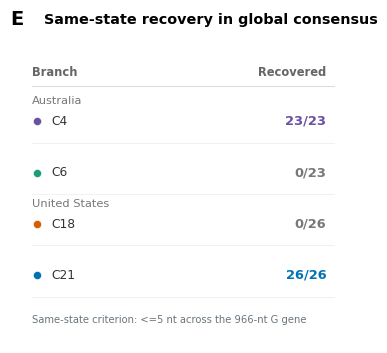

In [5]:
fig, paths = au.draw_global_context(summary, FIG_DIR)
display(paths)
plt.show()
